<a href="https://colab.research.google.com/github/ASaragga/GRF/blob/main/VaR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nota: No Google Colab por vezes aparecem mensagens resultantes de uma brincadeira que o Google Colab decidiu fazer no dia 1 Abril de 2024, mas que mantém. Podemos retirar essas interrupções em Settings > Miscellaneous > Power Level, escolhendo: No Power

# Instalação

Vamos instalar as bibliotecas:  `Caramel.j` e `HypothesisTests.jl`.

`Plots.jl` a biblioteca de gráficos que iremos também utilizar, faz parte do muito reduzido conjunto de bibliotecas que já vêm instaladas no Google Colab, não sendo por isso necessário fazer Pkg.add("Plots")

In [ ]:
import Pkg
Pkg.add(url="https://github.com/ASaragga/Caramel.jl")
Pkg.add("HypothesisTests");

    Updating git-repo `https://github.com/ASaragga/Caramel.jl`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`
   Resolving package versions...
  No Changes to `~/.julia/environments/v1.10/Project.toml`
  No Changes to `~/.julia/environments/v1.10/Manifest.toml`


In [ ]:
using Caramel
using HypothesisTests
using Plots

Podemos guardar os gráficos criados por Plots, fazendo: `savefig(grafico, "nome_ficheiro")`

Exemplo: `savefig(grf01, "output.png")`

# Obtenção de Cotações e Visualização

Pretendemos obter as cotações diárias (ajustadas) de fecho da Apple, entre 1 Outubro 2020 e 15 de Março de 2025. Podemos, claro, escolher outras ações e períodos!

Para ações cotadas na Euronext Lisbon devemos acrescentar o sufixo (.LS) referente à bolsa,  e.g. "JMT.LS" para as ações da Jerónimo Martins.

In [ ]:
simbolo = "AAPL"                # "AAPL" é o símbolo da Apple na bolsa NASDAQ

preços = AssetPrice(simbolo, Date(2020,10,01), Date(2025,03,15)) |> DataFrame
show(preços)

1118×3 DataFrame
  Row │ ticker  date        adjclose
      │ String  Date        Float64
──────┼──────────────────────────────
    1 │ AAPL    2020-10-01   113.882
    2 │ AAPL    2020-10-02   110.206
    3 │ AAPL    2020-10-05   113.599
    4 │ AAPL    2020-10-06   110.342
    5 │ AAPL    2020-10-07   112.214
    6 │ AAPL    2020-10-08   112.107
    7 │ AAPL    2020-10-09   114.057
    8 │ AAPL    2020-10-12   121.302
    9 │ AAPL    2020-10-13   118.084
   10 │ AAPL    2020-10-14   118.172
   11 │ AAPL    2020-10-15   117.704
  ⋮   │   ⋮         ⋮          ⋮
 1109 │ AAPL    2025-03-03   238.03
 1110 │ AAPL    2025-03-04   235.93
 1111 │ AAPL    2025-03-05   235.74
 1112 │ AAPL    2025-03-06   235.33
 1113 │ AAPL    2025-03-07   239.07
 1114 │ AAPL    2025-03-10   227.48
 1115 │ AAPL    2025-03-11   220.84
 1116 │ AAPL    2025-03-12   216.98
 1117 │ AAPL    2025-03-13   209.68
 1118 │ AAPL    2025-03-14   213.49
                    1097 rows omitted

Selecionamos todas as linhas (:) mas apenas a coluna `:adjclose` para criar um vector contendo somente as cotações de fecho ajustadas em vez da totalidade do dataframe que tinhamos antes

In [ ]:
adjclose = preços[:, :adjclose];
# O ponto e virgula no final, faz com que o resultado do comando não seja impresso.


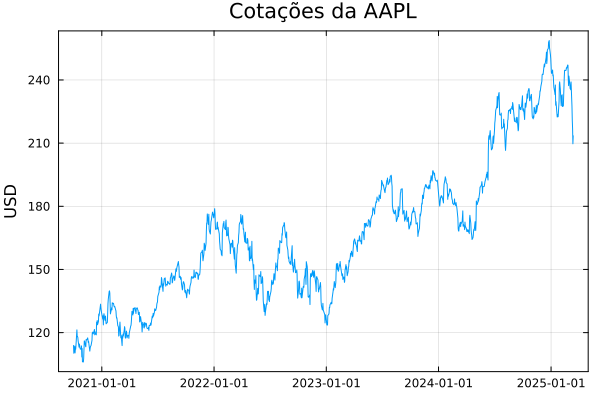

In [ ]:
fig1 = plot(preços[:,:date], adjclose, title="Cotações da $(simbolo)",legend = false,ylabel="USD", framestyle = :box)

# $(a) faz a interpolação do valor da variavel (a) no texto.

# Calcular Retornos

Para analisar séries cronológicas é normalmente mais indicado a utilização de retornos logarítmicos: $\log(P_t/P_{t-1})$. Julia denota por $\log(\cdot)$ a função que calcula o logarítmo de base e. Para agregação sectional, por exemplo se pretendermos calcular o retorno de uma carteira, devemos antes utilizar os retornos simples dos ativos constituintes da carteira: $(P_t-P_{t-1})/P_{t-1}$

In [ ]:
# Agora que inspecionámos a evolução das cotações, vamos calcular os retornos

logr = LogReturn(simbolo, Date(2020,10,01),Date(2025,01,01)) |> DataFrame
show(logr)

1068×5 DataFrame
  Row │ ticker  date        interval  type    returns
      │ String  Date        String    String  Float64
──────┼─────────────────────────────────────────────────
    1 │ AAPL    2020-10-02  1d        log     -0.032813
    2 │ AAPL    2020-10-05  1d        log      0.030326
    3 │ AAPL    2020-10-06  1d        log     -0.029089
    4 │ AAPL    2020-10-07  1d        log      0.016825
    5 │ AAPL    2020-10-08  1d        log     -0.000956
    6 │ AAPL    2020-10-09  1d        log      0.017246
    7 │ AAPL    2020-10-12  1d        log      0.061585
    8 │ AAPL    2020-10-13  1d        log     -0.026886
    9 │ AAPL    2020-10-14  1d        log      0.000743
   10 │ AAPL    2020-10-15  1d        log     -0.003969
   11 │ AAPL    2020-10-16  1d        log     -0.014099
  ⋮   │   ⋮         ⋮          ⋮        ⋮         ⋮
 1059 │ AAPL    2024-12-17  1d        log      0.009673
 1060 │ AAPL    2024-12-18  1d        log     -0.021655
 1061 │ AAPL    2024-12-19  1d        

In [ ]:
# Selecionamos todas as linhas do dataframe (logr) e apenas a coluna :returns

returns = logr[:, :returns];

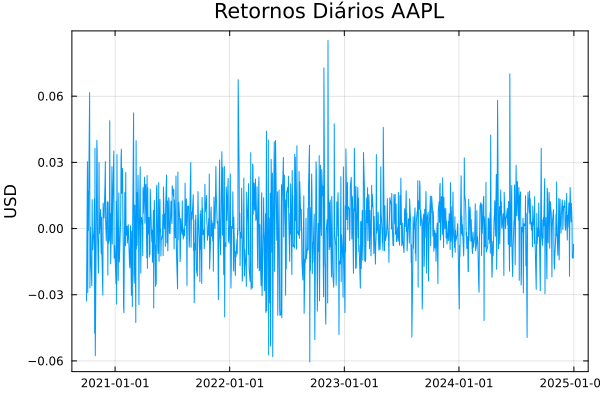

In [ ]:
fig2 = plot(logr[:,:date], returns, title="Retornos Diários $(simbolo)",legend = false, ylabel="USD", framestyle = :box)

## Média e Volatilidade

Iremos calcular de seguida (i) a média (μ) e o (ii) desvio-padrão (σ) dos retornos diários,

In [ ]:
mu = mean(returns)
sigma = std(returns)
println("μ = ", mu)
println("σ = ", sigma)

μ = 0.0007367790262172284
σ = 0.017069944728404583


Podemos obter algumas estatísticas adicionais de sumarização relativamente aos retornos usando o método `describe`.

In [ ]:
describe(returns)

Summary Stats:
Length:         1068
Missing Count:  0
Mean:           0.000737
Std. Deviation: 0.017070
Minimum:        -0.060472
1st Quartile:   -0.008214
Median:         0.001095
3rd Quartile:   0.010287
Maximum:        0.085237
Type:           Float64


## Histograma

Podemos visualizar o histograma dos retorns diário usando o método `histogram()` da bilioteca Plots.jl

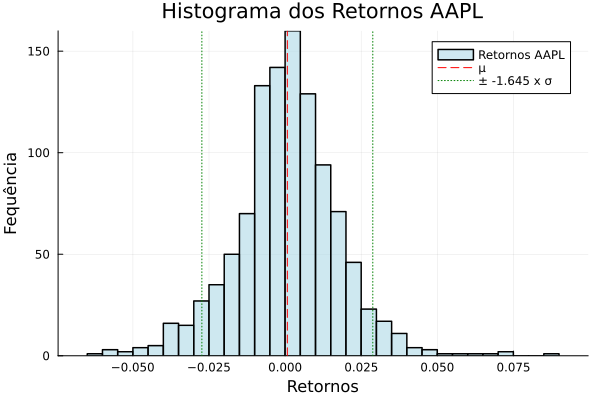

In [ ]:
fig3 = histogram(returns,
          bins=30,  # Numero de barras
          color=:lightblue,
          label="Retornos $(simbolo)",
          xlabel="Retornos",
          ylabel="Fequência",
          title="Histograma dos Retornos $(simbolo)",
          grid=true,
          fillalpha=0.6,  # Transparencia das barras
          linecolor=:black,
          linewidth=1.5)

# Adicionamos linhas verticais (vline!) para a média e z * desvio-padrão
z = - 1.645   # quantil a 5% se distribuição normal(0,1)

vline!([mu], linecolor=:red, linestyle=:dash, label="μ")
vline!([mu + z * sigma, mu - z * sigma],
       linecolor=:green, linestyle=:dot, label="± $(z) x σ")

display(plot!(fig3))

O gráfico (fig3) sugere que a observação de valores extremos ocorreu com elevada frequência

Primeiro ajustamos a distribuição Normal aos retornos observados, o que é muito simples

In [24]:
μ, σ = mean(returns), std(returns)
normal_fit = Normal(μ, σ)
println("Parâmetros: ", normal_fit)


Parâmetros: Normal{Float64}(μ=0.001089132958801498, σ=0.01662947067967996)


# Valor-em-Risco (VaR)

## Abordagem Analítica

Vamos agora determinar o valor em risco de acordo com a abordagem analítica.
1.   Escolhemos a distribuição de probabilidades.
2.   Selecionamos o período da amostra e estimamos o desvio-padrão ($\sigma_p$) da distribuição escolhida com base nos dados da amostra
  *   Podemos também considerar o valor esperado dos retornos $\mathbb{E}[\mu]$ com base num modelo de equilíbrio forward-looking, como CAPM.
  *   Pelo contrário, normalmente a volatilidade é estimada com base em dados históricos.
3.   Com base na distribução escolhida, calculamos o $\alpha$-quantil ($z_\alpha$) desejado.

Iremos considerar que $\mathbb{E}[\mu]\approx 0$, donde que neste caso teremos que

$$\text{VaR}_\alpha = - z_\alpha * \sigma_p * V_p$$

onde $V_p$ é o valor do portfolio. Assumimos que a distribuição de retornos é a Normal.

In [28]:
V = 100_000
𝛼 = 0.05

z_𝛼 = quantile(Normal(),𝛼)
VaR = - z_𝛼 * σ * V
println("Abordagem Analítica: VaR(𝛼=$(𝛼)) = ", VaR)

Abordagem Analítica: VaR(𝛼=0.05) = 2735.3045161754753


# Simulação Histórica

O cálculo do VaR por simulação histórica requer apenas que determinemos o ponto de corte correspondente ao $\alpha$-quantil para o período da amostra.

In [ ]:
VaR = - quantile(returns, 𝛼) * V
println("Simulação Histórica: VaR(𝛼=$(𝛼)) = ", VaR)

Simulação Histórica: VaR(𝛼=0.05) = 2757.5000000000005
